# **06 Structured Output - 원하는 형태로 데이터 반환하기**

### 학습 내용
1. Structured Output의 개념과 필요성
2. Pydantic BaseModel로 출력 스키마 정의
3. with_structured_output() 사용법
4. 여러 스키마 처리 (Union 타입)
5. Structured Output Agent 구현
6. ArXiv Tool을 활용한 논문 정보 Agent

## 1. 환경 설정

In [12]:
import warnings
warnings.filterwarnings("ignore", message="Pydantic serializer warnings")

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 2. Structured Output이란?

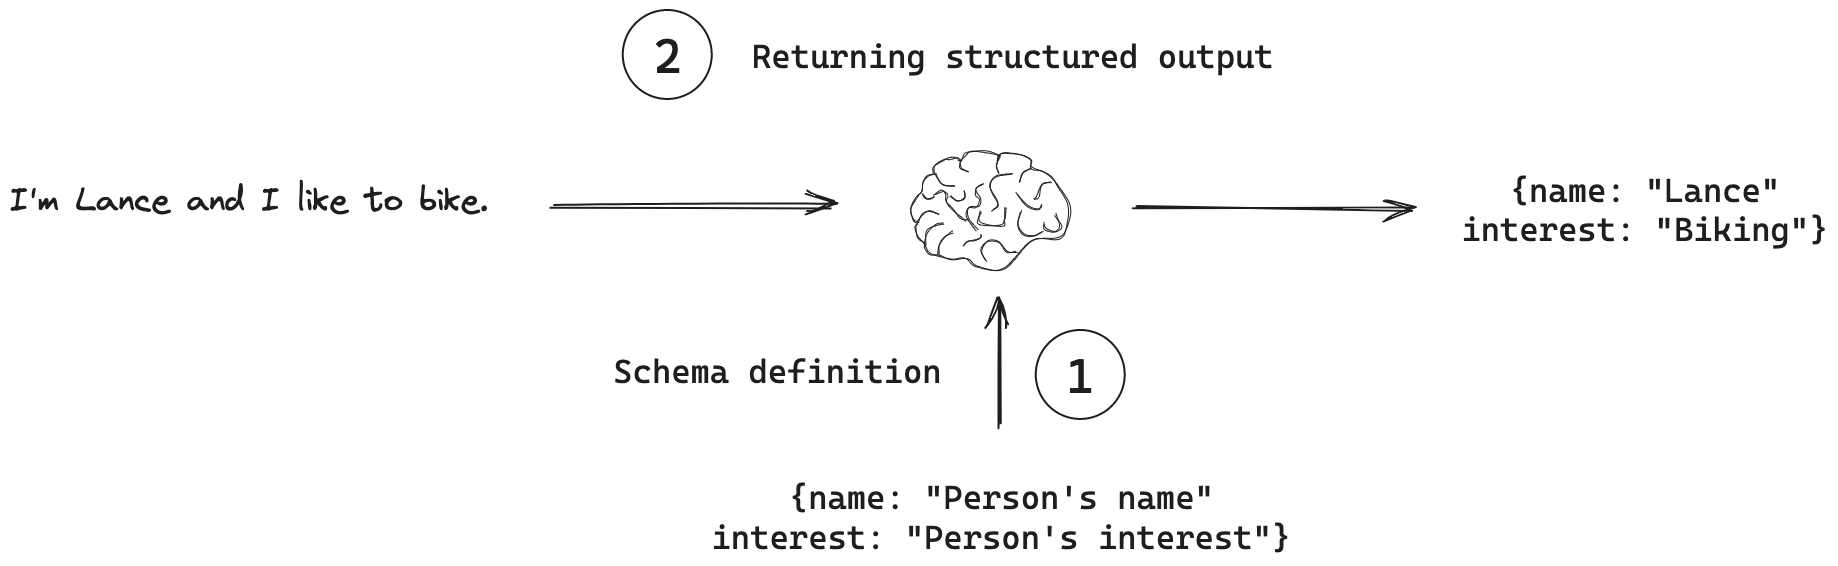

**Structured Output**은 LLM의 응답을 정해진 형식으로 받는 기능입니다.

### 왜 필요한가?

| 문제점 | 해결책 |
|-------|-------|
| LLM 응답이 자유 형식 | 고정된 스키마로 응답 |
| 파싱 및 검증 어려움 | 자동 타입 변환 및 검증 |
| 일관성 없는 형식 | 항상 동일한 구조 보장 |
| 다른 시스템과 연동 어려움 | 구조화된 데이터로 쉬운 연동 |

### 사용 시나리오

- **데이터 추출**: 문서에서 특정 정보 추출
- **데이터베이스 저장**: 구조화된 데이터로 DB 저장
- **API 응답**: JSON 형태로 클라이언트에 전달
- **Agent 워크플로우**: 다음 노드에 구조화된 데이터 전달

## 3. 기본 Structured Output

### 3-1. Pydantic BaseModel 정의

출력 형식을 Pydantic 모델로 정의합니다.

In [3]:
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model

# 영화 정보 스키마
class MovieResponse(BaseModel):
    """영화 정보를 반환합니다."""

    title: str = Field(description="영화 제목")
    director: str = Field(description="감독 이름")
    genre: str = Field(description="장르")
    release_year: int = Field(description="개봉 연도")

### 3-2. with_structured_output() 사용

`with_structured_output()`을 사용하여 LLM이 구조화된 응답을 반환하도록 합니다.

In [4]:
# LLM 초기화
model = init_chat_model("gpt-4o-mini")

# Structured Output 설정
model_with_structured_output = model.with_structured_output(MovieResponse)

### 3-3. 구조화된 응답 받기

In [13]:
# 영화 정보 요청
response = model_with_structured_output.invoke("타이타닉 영화에 대해 설명해주세요.")

print("응답 타입:", type(response))
print("\n영화 정보:")
print(response)
print(f"\n제목: {response.title}")
print(f"감독: {response.director}")
print(f"장르: {response.genre}")
print(f"개봉 연도: {response.release_year}")

응답 타입: <class '__main__.MovieResponse'>

영화 정보:
title='타이타닉' director='제임스 카메론' genre='드라마, 로맨스' release_year=1997

제목: 타이타닉
감독: 제임스 카메론
장르: 드라마, 로맨스
개봉 연도: 1997


In [14]:
# 다른 영화로 테스트
response = model_with_structured_output.invoke("인셉션 영화 정보를 알려주세요.")
print(response)

title='인셉션' director='크리스토퍼 놀란' genre='SF, 액션, 드라마' release_year=2010


### 📖 과제 1: 도서 정보 Structured Output

도서 정보를 구조화된 형식으로 반환하는 시스템을 만드세요.

**요구사항**:
1. `BookResponse` 스키마 정의 (title, author, publication_year, isbn, summary)
2. `get_bookinfo` Tool: 더미 도서 정보 반환 (3권 이상)
3. Structured Output으로 도서 정보 생성
4. 여러 도서로 테스트

**힌트**: 
- MovieResponse를 참고하여 BookResponse 작성
- Literal 타입으로 특정 도서만 처리
- `with_structured_output()` 사용

**예상 출력**:
```
도서 정보:
제목: 해리포터와 마법사의 돌
저자: J.K. 롤링
출판연도: 1997
ISBN: 978-0439708180
```

In [36]:
# CODE HERE

<details>

<summary>모범 답안 펼쳐보기</summary>

```python
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from typing import Literal
from langchain_core.tools import tool

# 1. 도서 정보 스키마 정의
class BookResponse(BaseModel):
    """도서 정보를 반환합니다."""
    
    title: str = Field(description="도서 제목")
    author: str = Field(description="저자 이름")
    publication_year: int = Field(description="출판 연도")
    isbn: str = Field(description="ISBN 번호")
    summary: str = Field(description="도서 요약")


# 2. 도서 정보 Tool 정의
@tool
def get_bookinfo(book: Literal["해리포터와 마법사의 돌", "1984", "어린왕자"]):
    """도서 정보를 조회합니다."""
    
    if book == "해리포터와 마법사의 돌":
        return """
        제목: 해리포터와 마법사의 돌
        저자: J.K. 롤링
        출판연도: 1997
        ISBN: 978-0439708180
        요약: 부모를 잃고 이모부 집에서 자란 해리 포터가 11세 생일에 자신이 마법사임을 알게 되고, 
        호그와트 마법학교에 입학하여 친구들과 함께 모험을 겪는 이야기입니다.
        """
    elif book == "1984":
        return """
        제목: 1984
        저자: 조지 오웰
        출판연도: 1949
        ISBN: 978-0451524935
        요약: 전체주의 국가 오세아니아를 배경으로 한 디스토피아 소설로, 
        개인의 자유와 사생활이 완전히 통제당하는 사회에서 주인공 윈스턴의 저항을 그립니다.
        """
    elif book == "어린왕자":
        return """
        제목: 어린왕자
        저자: 생텍쥐페리
        출판연도: 1943
        ISBN: 978-0156012195
        요약: 사막에 불시착한 비행사가 만난 어린 왕자와의 대화를 통해 
        진정한 사랑과 우정, 삶의 본질에 대해 이야기하는 철학적 동화입니다.
        """
    else:
        raise AssertionError(f"Unknown book: {book}")


# 3. LLM 초기화 및 Structured Output 설정
model = init_chat_model("gpt-4o-mini")
model_with_structured_output = model.with_structured_output(BookResponse)


# 4. Tool 바인딩
tools = [get_bookinfo]
model_with_tool = model.bind_tools(tools)


# 5. 여러 도서로 테스트
test_books = [
    "해리포터와 마법사의 돌에 대해 알려주세요.",
    "1984 책 정보를 알려줘.",
    "어린왕자를 소개해주세요."
]

for query in test_books:
    print("\n" + "="*70)
    print(f"질문: {query}\n")
    
    # Step 1: Tool 호출 결정
    response = model_with_tool.invoke([("user", query)])
    
    # Step 2: Tool 실행
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        tool_result = get_bookinfo.invoke(tool_call["args"])
        
        # Step 3: Structured Output 생성
        book_info = model_with_structured_output.invoke([
            ("user", f"다음 정보를 구조화해주세요:\n{tool_result}")
        ])
        
        print("도서 정보:")
        print(f"제목: {book_info.title}")
        print(f"저자: {book_info.author}")
        print(f"출판연도: {book_info.publication_year}")
        print(f"ISBN: {book_info.isbn}")
        print(f"요약: {book_info.summary}")
```


</details>

## 4. 여러 스키마 처리하기

상황에 따라 다른 형식으로 응답하도록 `Union` 타입을 사용합니다.

### 4-1. 여러 스키마 정의

In [16]:
from typing import Union

class MovieResponse(BaseModel):
    """영화 정보를 반환합니다."""

    title: str = Field(description="영화 제목")
    director: str = Field(description="감독 이름")
    genre: str = Field(description="장르")
    release_year: int = Field(description="개봉 연도")

class ConversationalResponse(BaseModel):
    """일반 대화로 응답합니다. 친절하고 도움이 되도록 답변하세요."""

    response: str = Field(description="사용자 질문에 대한 대화형 응답")

class FinalResponse(BaseModel):
    """최종 응답 형식"""

    final_output: Union[MovieResponse, ConversationalResponse]

### 4-2. Union 스키마로 모델 생성

In [17]:
# Union 타입으로 Structured Output 생성
structured_llm = model.with_structured_output(FinalResponse)

### 4-3. 다양한 질문 테스트

In [18]:
# 영화 정보 요청 → MovieResponse
response = structured_llm.invoke("타이타닉에 대해 알려주세요.")
print("응답 타입:", type(response.final_output))
print(response.final_output)

응답 타입: <class '__main__.MovieResponse'>
title='타이타닉' director='제임스 카메론' genre='드라마, 로맨스' release_year=1997


In [19]:
# 일반 대화 → ConversationalResponse
response = structured_llm.invoke("오늘 기분 어때?")
print("응답 타입:", type(response.final_output))
print(response.final_output)

응답 타입: <class '__main__.ConversationalResponse'>
response='많이 좋습니다! 당신은 어떻게 지내고 계신가요?'


## 5. Structured Output을 사용하는 Agent

Tool을 사용하여 정보를 가져온 후, 구조화된 형식으로 응답하는 Agent를 만듭니다.

### 5-1. State 정의

`MessagesState`를 상속하여 메시지와 최종 응답을 관리합니다.

In [20]:
from langgraph.graph import MessagesState

class MovieState(MessagesState):
    final_response: MovieResponse

### 5-2. 영화 정보 Tool 정의

In [21]:
from typing import Literal
from langchain_core.tools import tool

@tool
def get_movieinfo(movie: Literal["타이타닉", "노팅힐", "인셉션"]):
    """영화 정보를 조회합니다."""

    if movie == "타이타닉":
        return "영화 타이타닉은 1997년 개봉하였고, 감독은 제임스 카메론입니다. 장르는 로맨스/드라마입니다."
    elif movie == "노팅힐":
        return "영화 노팅힐은 1999년 개봉하였고, 감독은 로저 미첼입니다. 장르는 로맨틱 코미디입니다."
    elif movie == "인셉션":
        return "영화 인셉션은 2010년 개봉하였고, 감독은 크리스토퍼 놀란입니다. 장르는 SF/액션입니다."
    else:
        raise AssertionError(f"Unknown movie: {movie}")

### 5-3. Agent 노드 정의

#### LLM 노드 - Tool 호출 결정

In [22]:
# Tool 바인딩
tools = [get_movieinfo]
model_with_tool = model.bind_tools(tools)

def call_model(state: MovieState):
    """LLM을 호출하여 Tool 사용 여부를 결정합니다."""
    response = model_with_tool.invoke(state["messages"])
    return {"messages": [response]}

#### 응답 노드 - 구조화된 응답 생성

In [23]:
from langchain_core.messages import HumanMessage

# Structured Output 모델
model_with_structured_output = model.with_structured_output(MovieResponse)

def respond(state: MovieState):
    """Tool 실행 결과를 기반으로 구조화된 응답을 생성합니다."""

    # messages[-2]는 ToolMessage (Tool 실행 결과)
    response = model_with_structured_output.invoke(
        [HumanMessage(content=state["messages"][-2].content)]
    )

    return {"final_response": response}

#### 조건부 로직

In [24]:
from typing import Literal

def should_continue(state: MovieState) -> Literal["continue", "respond"]:
    """Tool 호출 여부에 따라 다음 동작을 결정합니다."""

    last_message = state["messages"][-1]

    if not last_message.tool_calls:
        return "respond"
    else:
        return "continue"

### 5-4. Agent 그래프 구성

In [25]:
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

# 그래프 빌더
graph_builder = StateGraph(MovieState)

# 노드 추가
graph_builder.add_node("agent", call_model)
graph_builder.add_node("respond", respond)
graph_builder.add_node("tools", ToolNode(tools))  # Tool 실행 노드

# 엣지 연결
graph_builder.set_entry_point("agent")

graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "respond": "respond",
    },
)

graph_builder.add_edge("tools", "agent")  # Tool → Agent (반복)
graph_builder.add_edge("respond", END)

# 컴파일
movie_graph = graph_builder.compile()

### 5-5. 그래프 시각화

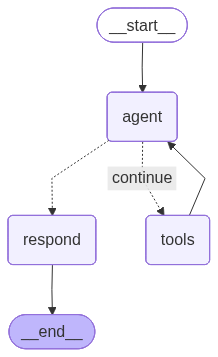

In [26]:
from IPython.display import Image, display

try:
    display(Image(movie_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### 5-6. Agent 실행

In [27]:
# 타이타닉 정보 조회
result = movie_graph.invoke(
    input={"messages": [("human", "타이타닉 영화에 대해 알려주세요.")]}
)

answer = result["final_response"]
print("="*60)
print("영화 정보:")
print(f"제목: {answer.title}")
print(f"감독: {answer.director}")
print(f"장르: {answer.genre}")
print(f"개봉 연도: {answer.release_year}")

영화 정보:
제목: 타이타닉
감독: 제임스 카메론
장르: 로맨스/드라마
개봉 연도: 1997


In [28]:
# 노팅힐 정보 조회
result = movie_graph.invoke(
    input={"messages": [("human", "영화 노팅힐의 정보를 알려줘.")]}
)

answer = result["final_response"]
print("="*60)
print("영화 정보:")
print(answer)

영화 정보:
title='노팅힐' director='로저 미첼' genre='로맨틱 코미디' release_year=1999


## 6. ArXiv Tool을 활용한 논문 정보 Agent

실제 ArXiv API를 사용하여 논문 정보를 조회하고 구조화된 형식으로 반환합니다.

### 6-1. ArXiv Tool 설치 및 테스트

```bash
pip install arxiv
```

https://docs.langchain.com/oss/python/integrations/retrievers/arxiv

In [31]:
from langchain_community.retrievers import ArxivRetriever

retriever = ArxivRetriever(
    load_max_docs=2,
    get_full_documents=True,
)

#### ArXiv ID로 논문 조회

In [32]:
docs = retriever.invoke("1605.08386")
print("논문 정보:")
print(docs)

논문 정보:
[Document(metadata={'Published': '2016-05-26', 'Title': 'Heat-bath random walks with Markov bases', 'Authors': 'Caprice Stanley, Tobias Windisch', 'Summary': 'Graphs on lattice points are studied whose edges come from a finite set of allowed moves of arbitrary length. We show that the diameter of these graphs on fibers of a fixed integer matrix can be bounded from above by a constant. We then study the mixing behaviour of heat-bath random walks on these graphs. We also state explicit conditions on the set of moves so that the heat-bath random walk, a generalization of the Glauber dynamics, is an expander in fixed dimension.'}, page_content='arXiv:1605.08386v1  [math.CO]  26 May 2016\nHEAT-BATH RANDOM WALKS WITH MARKOV BASES\nCAPRICE STANLEY AND TOBIAS WINDISCH\nAbstract. Graphs on lattice points are studied whose edges come from a ﬁnite set of\nallowed moves of arbitrary length. We show that the diameter of these graphs on ﬁbers of a\nﬁxed integer matrix can be bounded from abov

In [33]:
docs = retriever.invoke("2312.15166")
print("논문 정보:")
print(docs)

논문 정보:
[Document(metadata={'Published': '2024-04-04', 'Title': 'SOLAR 10.7B: Scaling Large Language Models with Simple yet Effective Depth Up-Scaling', 'Authors': 'Dahyun Kim, Chanjun Park, Sanghoon Kim, Wonsung Lee, Wonho Song, Yunsu Kim, Hyeonwoo Kim, Yungi Kim, Hyeonju Lee, Jihoo Kim, Changbae Ahn, Seonghoon Yang, Sukyung Lee, Hyunbyung Park, Gyoungjin Gim, Mikyoung Cha, Hwalsuk Lee, Sunghun Kim', 'Summary': 'We introduce SOLAR 10.7B, a large language model (LLM) with 10.7 billion parameters, demonstrating superior performance in various natural language processing (NLP) tasks. Inspired by recent efforts to efficiently up-scale LLMs, we present a method for scaling LLMs called depth up-scaling (DUS), which encompasses depthwise scaling and continued pretraining. In contrast to other LLM up-scaling methods that use mixture-of-experts, DUS does not require complex changes to train and inference efficiently. We show experimentally that DUS is simple yet effective in scaling up high-per

In [34]:
docs = retriever.invoke("1605.08386WWW")
print(docs)

[]


### 6-2. 논문 정보 스키마 정의

In [35]:
from pydantic import BaseModel, Field

class PaperResponse(BaseModel):
    """논문 정보를 반환합니다."""

    published: str = Field(description="논문 게시 날짜")
    title: str = Field(description="논문 제목")
    authors: list[str] = Field(description="논문 저자 목록")
    summary: str = Field(description="논문 요약")

### 6-3. 논문 Agent State 정의

In [36]:
from langgraph.graph import MessagesState

class PaperState(MessagesState):
    final_response: PaperResponse

### 6-4. 논문 조회 Tool 정의

In [37]:
from langchain_core.tools import tool

@tool
def get_paper(arxiv_id: str):
    """ArXiv ID로 논문 정보를 조회합니다.

    Args:
        arxiv_id: ArXiv 논문 ID (예: 1605.08386)
    """
    paper = retriever.invoke(arxiv_id)
    return paper

### 6-5. 논문 Agent 노드 정의

In [38]:
# Tool 바인딩
paper_tools = [get_paper]
model = init_chat_model("gpt-4o-mini")
model_with_paper_tool = model.bind_tools(paper_tools)

def call_model(state: PaperState):
    """LLM을 호출하여 Tool 사용 여부를 결정합니다."""
    response = model_with_paper_tool.invoke(state["messages"])
    return {"messages": [response]}

# Structured Output 모델
model_with_structured_output = model.with_structured_output(PaperResponse)

def respond(state: PaperState):
    """Tool 실행 결과를 기반으로 구조화된 논문 정보를 생성합니다."""

    # messages[-2]는 ToolMessage (Tool 실행 결과)
    response = model_with_structured_output.invoke(
        [HumanMessage(content=state["messages"][-2].content)]
    )

    return {"final_response": response}

### 6-6. 논문 Agent 그래프 구성

In [39]:
def should_continue(state: PaperState) -> Literal["continue", "respond"]:
    """Tool 호출 여부에 따라 다음 동작을 결정합니다."""

    last_message = state["messages"][-1]

    if not last_message.tool_calls:
        return "respond"
    else:
        return "continue"

# 그래프 빌더
paper_graph_builder = StateGraph(PaperState)

# 노드 추가
paper_graph_builder.add_node("agent", call_model)
paper_graph_builder.add_node("respond", respond)
paper_graph_builder.add_node("tools", ToolNode(paper_tools))

# 엣지 연결
paper_graph_builder.set_entry_point("agent")

paper_graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "respond": "respond",
    },
)

paper_graph_builder.add_edge("tools", "agent")
paper_graph_builder.add_edge("respond", END)

# 컴파일
paper_graph = paper_graph_builder.compile()

### 6-7. 그래프 시각화

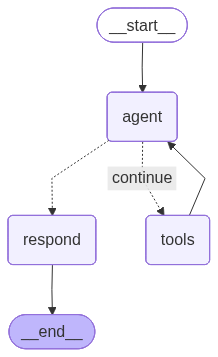

In [40]:
try:
    display(Image(paper_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### 6-8. 논문 Agent 실행

In [41]:
result = paper_graph.invoke(
    input={"messages": [("human", "2312.15166 논문에 대해 알려줘.")]}
)

answer = result["final_response"]

print("="*60)
print("논문 정보:")
print(f"\n게시일: {answer.published}")
print(f"\n제목: {answer.title}")
print(f"\n저자: {', '.join(answer.authors)}")
print(f"\n요약:\n{answer.summary}")

논문 정보:

게시일: 2024-04-04

제목: SOLAR 10.7B: Scaling Large Language Models with Simple yet Effective Depth Up-Scaling

저자: Dahyun Kim, Chanjun Park, Sanghoon Kim, Wonsung Lee, Wonho Song, Yunsu Kim, Hyeonwoo Kim, Yungi Kim, Hyeonju Lee, Jihoo Kim, Changbae Ahn, Seonghoon Yang, Sukyung Lee, Hyunbyung Park, Gyoungjin Gim, Mikyoung Cha, Hwalsuk Lee, Sunghun Kim

요약:
We introduce SOLAR 10.7B, a large language model (LLM) with 10.7 billion parameters, demonstrating superior performance in various natural language processing (NLP) tasks. Inspired by recent efforts to efficiently up-scale LLMs, we present a method for scaling LLMs called depth up-scaling (DUS), which encompasses depthwise scaling and continued pretraining. In contrast to other LLM up-scaling methods that use mixture-of-experts, DUS does not require complex changes to train and inference efficiently. We show experimentally that DUS is simple yet effective in scaling up high-performance LLMs from small ones. Building on the DUS mo

In [42]:
result = paper_graph.invoke(
    input={"messages": [("human", "1605.08386 논문 정보를 알려주세요.")]}
)

answer = result["final_response"]
print("="*60)
print(answer)

published='2016-05-26' title='Heat-bath random walks with Markov bases' authors=['Caprice Stanley', 'Tobias Windisch'] summary='Graphs on lattice points are studied whose edges come from a finite set of allowed moves of arbitrary length. We show that the diameter of these graphs on fibers of a fixed integer matrix can be bounded from above by a constant. We then study the mixing behaviour of heat-bath random walks on these graphs. We also state explicit conditions on the set of moves so that the heat-bath random walk, a generalization of the Glauber dynamics, is an expander in fixed dimension.'


In [43]:
print(f"논문 제목: {answer.title}")
print(f"\n첫 번째 저자: {answer.authors[0]}")
print(f"\n전체 저자 수: {len(answer.authors)}")

논문 제목: Heat-bath random walks with Markov bases

첫 번째 저자: Caprice Stanley

전체 저자 수: 2


In [44]:
result = paper_graph.invoke(
    input={"messages": [("human", "안녕하세요")]}
)

answer = result["final_response"]
print("="*60)
print(answer)

published='2023-10-14' title='인공지능과 인간의 협력: 미래의 가능성' authors=['홍길동', '김철수', '이영희'] summary='이 논문에서는 인공지능(AI) 기술이 인간과 협력하여 수행할 수 있는 다양한 방법을 탐구하고, 이러한 협력이 미래에 어떻게 발전할 수 있는지를 논의한다. 특히, 의료, 교육, 제조업 등 여러 분야에서 AI가 인간의 능력을 보완하고 향상시키는 사례를 제시하며, 윤리적 고려사항과 함께 향후 연구 방향을 제안한다.'


### 📖 과제 2: 일반 답변도 할 수 있는 논문 정보 Agent

논문 정보를 반환할 필요없는 일반 답변도 반환할 수 있는 Agent를 만드세요.

**요구사항**:
1. `PaperResponse`, `ConversationalResponse` 스키마 정의

**힌트**: 
- Union 타입으로 여러 스키마 통합

In [ ]:
# CODE HERE

<details>

<summary>모범 답안 펼쳐보기</summary>

```python
from typing import Union
from pydantic import BaseModel, Field
from langgraph.graph import MessagesState, StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from typing import Literal

# 1. 스키마 정의

class PaperResponse(BaseModel):
    """논문 정보를 반환합니다."""

    published: str = Field(description="논문 게시 날짜")
    title: str = Field(description="논문 제목")
    authors: list[str] = Field(description="논문 저자 목록")
    summary: str = Field(description="논문 요약")


class ConversationalResponse(BaseModel):
    """일반 대화로 응답합니다. 친절하고 도움이 되도록 답변하세요."""

    response: str = Field(description="사용자 질문에 대한 대화형 응답")


class FinalResponse(BaseModel):
    """최종 응답 형식"""

    final_output: Union[PaperResponse, ConversationalResponse]


# 2. State 정의

class PaperState(MessagesState):
    final_response: Union[PaperResponse, ConversationalResponse]


# 3. ArXiv Retriever 및 Tool 정의 (기존과 동일)

from langchain_community.retrievers import ArxivRetriever
from langchain_core.tools import tool

retriever = ArxivRetriever(
    load_max_docs=2,
    get_full_documents=True,
)

@tool
def get_paper(arxiv_id: str):
    """ArXiv ID로 논문 정보를 조회합니다.

    Args:
        arxiv_id: ArXiv 논문 ID (예: 1605.08386)
    """
    paper = retriever.invoke(arxiv_id)
    return paper


# 4. Agent 노드 정의

# LLM 초기화
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Tool 바인딩
paper_tools = [get_paper]
model_with_paper_tool = model.bind_tools(paper_tools)

def call_model(state: PaperState):
    """LLM을 호출하여 Tool 사용 여부를 결정합니다."""
    response = model_with_paper_tool.invoke(state["messages"])
    return {"messages": [response]}


# Union 타입으로 Structured Output 생성
model_with_structured_output = model.with_structured_output(FinalResponse)

def respond(state: PaperState):
    """Tool 실행 결과를 기반으로 구조화된 응답을 생성하거나 일반 대화로 응답합니다."""

    # Tool이 호출되었는지 확인
    last_ai_message = None
    for msg in reversed(state["messages"]):
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            last_ai_message = msg
            break

    # Tool이 호출된 경우: messages[-2]는 ToolMessage (Tool 실행 결과)
    if last_ai_message and last_ai_message.tool_calls:
        response = model_with_structured_output.invoke(
            [HumanMessage(content=state["messages"][-2].content)]
        )
    else:
        # Tool이 호출되지 않은 경우: 일반 대화
        response = model_with_structured_output.invoke(state["messages"])

    return {"final_response": response.final_output}


# 5. 조건부 로직

def should_continue(state: PaperState) -> Literal["continue", "respond"]:
    """Tool 호출 여부에 따라 다음 동작을 결정합니다."""

    last_message = state["messages"][-1]

    if not last_message.tool_calls:
        return "respond"
    else:
        return "continue"


# 6. Agent 그래프 구성

paper_graph_builder = StateGraph(PaperState)

# 노드 추가
paper_graph_builder.add_node("agent", call_model)
paper_graph_builder.add_node("respond", respond)
paper_graph_builder.add_node("tools", ToolNode(paper_tools))

# 엣지 연결
paper_graph_builder.set_entry_point("agent")

paper_graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "respond": "respond",
    },
)

paper_graph_builder.add_edge("tools", "agent")
paper_graph_builder.add_edge("respond", END)

# 컴파일
paper_graph = paper_graph_builder.compile()


# 7. 그래프 시각화

from IPython.display import Image, display

try:
    display(Image(paper_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)


# 8. 다양한 시나리오로 테스트

test_cases = [
    ("테스트 1: 논문 정보 요청", "2312.15166 논문에 대해 알려줘."),
    ("테스트 2: 일반 대화", "안녕하세요! 오늘 날씨가 좋네요."),
    ("테스트 3: ArXiv 관련 일반 질문", "ArXiv가 뭔가요?"),
    ("테스트 4: 다른 논문 정보", "1605.08386 논문 정보를 알려주세요."),
]

for i, (test_name, query) in enumerate(test_cases):
    if i > 0:
        print("\n\n" + "="*70)
    else:
        print("="*70)

    print(test_name)
    print("="*70)

    result = paper_graph.invoke(
        input={"messages": [("human", query)]}
    )

    answer = result["final_response"]

    if isinstance(answer, PaperResponse):
        print("\n[논문 정보 응답]")
        print(f"\n게시일: {answer.published}")
        print(f"\n제목: {answer.title}")
        print(f"\n저자: {', '.join(answer.authors[:3])}..." if len(answer.authors) > 3 else f"\n저자: {', '.join(answer.authors)}")
        if len(answer.authors) > 3:
            print(f"\n전체 저자 수: {len(answer.authors)}")
        print(f"\n요약:\n{answer.summary}")
    else:
        print(f"\n[일반 응답]: {answer.response}")
```

---
### 참고 자료

- [LangChain Structured Output](https://python.langchain.com/docs/how_to/structured_output/)
- [ArXiv API Integration](https://docs.langchain.com/oss/python/integrations/retrievers/arxiv)